In [49]:
%pip -q install -U langgraph langchain langchain-openai

Note: you may need to restart the kernel to use updated packages.


In [50]:
import os
import re
from getpass import getpass
from typing import Literal, TypedDict
from dotenv import load_dotenv

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_openai import AzureChatOpenAI

from langgraph.graph import START, END, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition


In [51]:
load_dotenv()
endpoint = os.getenv("ENDPOINT")
api_key = os.getenv("API_KEY")
deployment_name = os.getenv("DEPLOYMENT_NAME")
api_version = os.getenv("API_VERSION")

# Quick sanity check 
print("Endpoint loaded:", endpoint is not None)
print("API key loaded:", api_key is not None)
print("Deployment name:", deployment_name)
print("API version:", api_version)

Endpoint loaded: True
API key loaded: True
Deployment name: GPT-Agents
API version: 2024-10-21


In [52]:
from openai import AzureOpenAI

client = AzureOpenAI(
    azure_endpoint=endpoint,
    api_key=api_key,
    api_version=api_version,
)

print("Client created successfully!")

Client created successfully!


In [53]:
response = client.chat.completions.create(
    model=deployment_name,  # this is your DEPLOYMENT name, not the base model name
    messages=[
        {"role": "system", "content": "You are a friendly assistant who explains things simply."},
        {"role": "user", "content": "In one sentence, what is a large language model?"}
    ],
    max_completion_tokens=200,
)

print(response.choices[0].message.content)

A large language model is an AI system trained on vast amounts of text to understand and generate human-like language.


In [54]:
my_question = "What are ETF, explain me like I am 5!"

response = client.chat.completions.create(
    model=deployment_name,
    messages=[
        {"role": "user", "content": my_question}
    ],
)

print(response.choices[0].message.content)

An **ETF** (Exchange-Traded Fund) is like a **basket of investments**.

Imagine you want fruit, but instead of buying only an apple, you buy a basket containing:

- An apple 🍎  
- A banana 🍌  
- An orange 🍊  

If one fruit isn’t good, you still have the others.

An ETF works similarly: instead of buying just one company’s stock, you can buy a small piece of many companies at once. For example, one ETF might contain shares of Apple, Microsoft, Amazon, and hundreds of other companies.

You can buy and sell ETFs on the stock market, just like individual stocks.

**Why people like ETFs:**
- They spread your money across many investments.
- They’re usually simple and inexpensive.
- They can be less risky than owning only one stock.

But ETFs can still lose value if the investments inside them go down.


## ReAct Agent with LangGraph, use as project's agent

A **ReAct agent** (Reasoning + Acting) loops between:
1. **Think** — the LLM decides whether to call a tool or answer directly
2. **Act** — if a tool is needed, LangGraph runs it
3. **Observe** — the result is fed back to the LLM

```
START → agent → tools_condition → tools → agent → ... → END
```

In [55]:
!pip install pandas

In [56]:
# Step 1: Create the LangChain LLM wrapper for Azure OpenAI
from pydantic import BaseModel, Field,ConfigDict
import pandas as pd
llm = AzureChatOpenAI(
    azure_endpoint=endpoint,
    api_key=api_key,
    azure_deployment=deployment_name,
    api_version=api_version
)

print("LLM ready:", deployment_name)


# Define your desired response schema using Pydantic
class ComparisonTableWithResponse(BaseModel):
    model_config = ConfigDict(arbitrary_types_allowed=True)
    etf1: str = ''
    etf2: str = ''
    etf3: str = ''
    sector: str = ''
    table : pd.DataFrame = pd.DataFrame({etf1:[], etf2:[],etf3:[]})

LLM ready: GPT-Agents


In [ ]:
# Replace or extend these with your own tools (APIs, databases, etc.)

@tool 
def compare(str1:str, str2:str, str3:str)-> str:
    """compare the ETFs mentioned, if 2 or 3 are provided"""
    if str3 == '':
       print("sure, we can compare these 2 ETFs.")
       comparison_data= "1 is better than 2."
       return(comparison_data)
    print("sure, we can compare these 3 ETFs.")
    comparison_data= "1 is better than 2. however the best one is 3"
    return(comparison_data)
tools = [multiply, add, get_word_length,say_hello,compare]
print("Tools defined:", [t.name for t in tools])

Tools defined: ['multiply', 'add', 'get_word_length', 'say_hello', 'compare']


In [81]:
# Step 3: Build the ReAct agent graph

llm_with_tools = llm.bind_tools(tools)

SYSTEM_PROMPT = SystemMessage(
    content="""You are a helpful assistant that compares ETFs and answers follow up questions. 
    Use tools whenever they help you give an accurate answer, and return unavailable data for anything that is not defined. 
    do not reccomend an ETF. 
    generate a table with etf names as the column names. the data for comparison is is the row names. 
    leave empty space below the table and generate a follow up response as needed. only pass data and do not summarize. 
    all of the data should be only retrieved from the Morningstar MCP. also return all of this data, origined in a json format, such that the a table can be made using pandas that has the etf name as the column names and the data as the row names like this: {
  "SPY": {
    "Recommendation": null,
    "Morningstar MCP data": null
  },
  "VOO": {
    "Recommendation": null,
    "Morningstar MCP data": null
  }
}."""
)

def call_model(state: MessagesState):
    """Agent node: invoke the LLM and return its response."""
    messages = [SYSTEM_PROMPT] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

graph = StateGraph(MessagesState)
graph.add_node("agent", call_model)
graph.add_node("tools", tool_node)

graph.add_edge(START, "agent")
graph.add_conditional_edges("agent", tools_condition)  # routes to "tools" or END
graph.add_edge("tools", "agent")                       # after tool runs, back to agent

agent = graph.compile()
print("ReAct agent compiled!")

ReAct agent compiled!


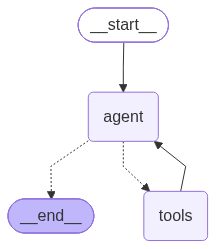

In [82]:
# Step 4: Visualize the graph (requires graphviz — skip if not installed)
from IPython.display import Image, display

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization unavailable:", e)
    print(agent.get_graph().draw_ascii())

In [95]:
# Step 5: Run the agent
import json
def run_agent(question: str):
    """Invoke the agent and print each step + final answer."""
    print(f"Question: {question}\n")
    result = agent.invoke({"messages": [HumanMessage(content=question)]})

    for msg in result["messages"]:
        role = msg.__class__.__name__
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            for tc in msg.tool_calls:
                print(f"  [Tool call] {tc['name']}({tc['args']})")
        elif hasattr(msg, "name") and msg.name:  # ToolMessage
            print(f"  [Tool result] {msg.name} → {msg.content}")
        else:
            print(f"  [{role}] {msg.content}")

    #print("\nFinal answer:", result["messages"][-1].content)
    return result

response = run_agent('reccomend between voo and voo?')
#print(response)
#raw_text = response.content.replace("```json", "").replace("```", "").strip()
#data = json.loads(raw_text)

  # 4. Convert to a DataFrame and show in Streamlit


import re

text = response["messages"][-1].content

match = re.search(r"```json\s*(.*?)\s*```", text, re.DOTALL)
data = ''
if match:
    json_str = match.group(1)
    data = json.loads(json_str)

    print('here is the json')
    print(data)
    print(type(data))
#this is the dataframe made from the json extracted from the AI response.    
df = pd.DataFrame(data)
df

Question: reccomend between voo and voo?

  [HumanMessage] reccomend between voo and voo?
  [AIMessage] | Data | VOO |
|---|---|
| Recommendation | Unavailable |
| Morningstar MCP data | Unavailable |


```json
{
  "VOO": {
    "Recommendation": null,
    "Morningstar MCP data": null
  }
}
```

Did you intend to compare VOO with a different ETF?
here is the json
{'VOO': {'Recommendation': None, 'Morningstar MCP data': None}}
<class 'dict'>


,VOO
Recommendation,None
Morningstar MCP data,None


This is the method to get the actual response from the data.

In [96]:
print(response["messages"][-1].content)

| Data | VOO |
|---|---|
| Recommendation | Unavailable |
| Morningstar MCP data | Unavailable |


```json
{
  "VOO": {
    "Recommendation": null,
    "Morningstar MCP data": null
  }
}
```

Did you intend to compare VOO with a different ETF?


this is a basic blueprint for making another agent if needed

In [ ]:
import os
from dotenv import load_dotenv

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_openai import AzureChatOpenAI

# --- Azure OpenAI setup ---
load_dotenv()
llm = AzureChatOpenAI(
    azure_endpoint=os.getenv("ENDPOINT"),
    api_key=os.getenv("API_KEY"),
    azure_deployment=os.getenv("DEPLOYMENT_NAME"),
    api_version=os.getenv("API_VERSION"),
)

# --- Tools ---
tools = [multiply, add]
llm_with_tools = llm.bind_tools(tools)
#llm_with_tools_structured_response = llm_with_tools.with_structured_output(ComparisonTableWithResponse)

# --- Ask a question ---
messages = [
    SystemMessage(content="You are a helpful assistant. Use tools when needed."),
    HumanMessage(content="What is 25 multiplied by 4, then add 50?"),
]
response = llm_with_tools.invoke(messages)
